# DATA ONLINE RETAIL 


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("online_retail.csv", encoding='latin1')
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Data ini merupakan data transaksi penjualan dari sebuah perusahaan ritel online (online retail). Data ini menggambarkan aktivitas pembelian pelanggan dalam suatu periode waktu tertentu, yang mencakup informasi seperti nomor faktur (invoice), kode produk, deskripsi produk, jumlah barang yang dibeli, tanggal dan waktu transaksi, harga satuan, serta identitas pelanggan.

Selain itu, data juga memuat informasi asal negara pelanggan, sehingga memungkinkan analisis berdasarkan wilayah geografis. Dari variabel jumlah (quantity) dan harga satuan (unit price), dapat dihitung total nilai transaksi untuk setiap pembelian. Data ini sangat berguna untuk menganalisis perilaku pelanggan, pola pembelian, produk yang paling diminati, serta tren penjualan dari waktu ke waktu.

Dengan adanya data ini, perusahaan dapat melakukan berbagai analisis seperti segmentasi pelanggan, perhitungan nilai transaksi, deteksi pembelian tidak wajar (outlier), hingga pengembangan strategi pemasaran yang lebih efektif berdasarkan kebiasaan belanja pelanggan.


Berikut adalah 5 baris pertama dan terakhir dari dataset

In [3]:
display(df.head(),df.tail())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


Data Understanding dan Cleaning

In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000

In [7]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


1454 data kosong pada variabel 'Description' dan 135080 pada variabel 'CustomerID' . Karena datanya bersifat kategorik, maka kita akan mencari modusnya (data kategorik tidak dapat dihitung rata-ratanya).

mengisi missing value pada variabel Description dan CustomerID 

In [6]:
df['Description'].fillna(df['Description'].mode()[0], inplace=True)
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
df['CustomerID'].fillna('Unknown', inplace=True)
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_13784\3944828728.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustomerID'].fillna('Unknown', inplace=True)


Setelah mengisi pada nilai kosong pada variabel income, kita dapat melihat bahwa semua missing value telah terisi dan tidak ada lagi variabel yang memiliki nilai yang kosong. Selanjutnya, kita akan mengecek deskripsi serta isi unik dari setiap variabel.

In [11]:

display(df.describe(), df.describe(include='object'))

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,11476.974671
std,218.081158,96.759853,6777.908326
min,-80995.000000,-11062.060000,0.000000
25%,1.000000,1.250000,12352.000000
50%,3.000000,2.080000,14382.000000
75%,10.000000,4.130000,16255.000000
max,80995.000000,38970.000000,18287.000000


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,541909,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2011-10-31 14:41:00,United Kingdom
freq,1114,2313,3823,1114,495478


Berdasarkan hasil statistik deskriptif, ditemukan adanya nilai negatif pada variabel Quantity dan UnitPrice yang menunjukkan data tidak valid. Selain itu, terdapat nilai maksimum yang sangat besar yang mengindikasikan adanya outlier. Oleh karena itu, diperlukan proses preprocessing lanjutan berupa filtering data untuk menghapus nilai negatif serta penanganan outlier agar data menjadi lebih bersih dan siap untuk analisis lebih lanjut.

In [21]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [14]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['TotalPrice_scaled'] = scaler.fit_transform(df[['TotalPrice']])

In [13]:
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['UnitPrice'] >= Q1 - 1.5*IQR) & (df['UnitPrice'] <= Q3 + 1.5*IQR)]

In [16]:
df.describe()

,Quantity,UnitPrice,CustomerID,TotalPrice,TotalPrice_scaled
count,492105.000000,492105.000000,492105.000000,492105.000000,4.921050e+05
mean,11.148015,2.531873,11670.079881,18.386959,2.364135e-17
std,161.387532,1.913865,6683.690513,271.496148,1.000001e+00
min,1.000000,0.001000,0.000000,0.001000,-6.772095e-02
25%,1.000000,1.250000,12438.000000,3.380000,-5.527509e-02
50%,4.000000,1.950000,14456.000000,8.400000,-3.678494e-02
75%,12.000000,3.750000,16340.000000,17.000000,-5.108581e-03
max,80995.000000,8.330000,18287.000000,168469.600000,6.204559e+02


Setelah dilakukan preprocessing, data sudah bebas dari nilai negatif dan missing value. Variabel UnitPrice telah menjadi lebih stabil, namun masih ditemukan outlier pada variabel Quantity dan TotalPrice. Oleh karena itu, dilakukan penanganan outlier menggunakan metode IQR agar distribusi data menjadi lebih representatif. Selain itu, normalisasi data menggunakan standardisasi telah berhasil, ditunjukkan dengan nilai mean mendekati 0 dan standar deviasi mendekati 1.

In [17]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['TotalPrice'] >= Q1 - 1.5*IQR) & 
        (df['TotalPrice'] <= Q3 + 1.5*IQR)]

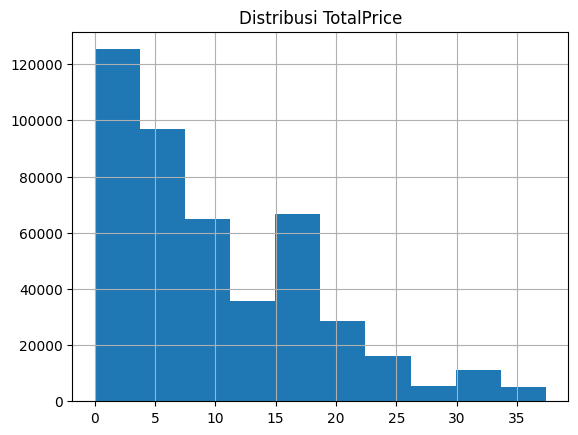

In [18]:
import matplotlib.pyplot as plt

df['TotalPrice'].hist()
plt.title("Distribusi TotalPrice")
plt.show()

In [19]:
import numpy as np
df['LogTotalPrice'] = np.log1p(df['TotalPrice'])

In [20]:
df.describe()

,Quantity,UnitPrice,CustomerID,TotalPrice,TotalPrice_scaled,LogTotalPrice
count,455881.000000,455881.000000,455881.000000,455881.000000,455881.000000,455881.000000
mean,6.513794,2.493775,11523.364459,9.953111,-0.031064,2.096055
std,9.028072,1.899257,6788.605965,8.089848,0.029797,0.809654
min,1.000000,0.001000,0.000000,0.001000,-0.067721,0.001000
25%,1.000000,1.250000,12360.000000,3.290000,-0.055607,1.456287
50%,3.000000,1.950000,14432.000000,7.530000,-0.039989,2.143589
75%,10.000000,3.360000,16342.000000,15.000000,-0.012475,2.772589
max,900.000000,8.330000,18287.000000,37.400000,0.070031,3.648057


Setelah dilakukan preprocessing, data telah mengalami perbaikan signifikan. Missing value telah ditangani, nilai negatif dan tidak valid telah dihapus, serta outlier berhasil dikurangi menggunakan metode IQR. Selain itu, dilakukan feature engineering dengan membuat variabel TotalPrice, serta normalisasi menggunakan standardisasi. Transformasi log juga diterapkan untuk mengurangi skewness distribusi data. Hasil akhir menunjukkan bahwa data menjadi lebih bersih, stabil.

Data transaksi memiliki kecenderungan skewed karena adanya pembelian dalam jumlah besar, sehingga transformasi log diperlukan untuk menstabilkan distribusi.

In [ ]:
df.to_csv("clean_online_retail.csv", index=False)

In [31]:
df_baru = pd.read_csv("clean_online_retail.csv")
df_baru.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,TotalPrice_scaled,LogTotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,0.660939,2.791165
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,1.283943,3.060583
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,1.489138,3.135494
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,1.283943,3.060583
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,1.283943,3.060583


Dataset yang telah dibersihkan kemudian disimpan dalam file baru untuk digunakan pada analisis selanjutnya.